## Import packages

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import integrate
import sys
import os
sys.path.append("../../../../")
from ADFWI.propagator  import *
from ADFWI.model       import *
from ADFWI.view        import *
from ADFWI.utils       import *
from ADFWI.survey      import *
from ADFWI.fwi         import *

project_path = "./examples/gradient_checking/Marmousi2/data"
if not os.path.exists(os.path.join(project_path,"model")):
    os.makedirs(os.path.join(project_path,"model"))
if not os.path.exists(os.path.join(project_path,"waveform")):
    os.makedirs(os.path.join(project_path,"waveform"))
if not os.path.exists(os.path.join(project_path,"survey")):
    os.makedirs(os.path.join(project_path,"survey"))
if not os.path.exists(os.path.join(project_path,"inversion-AD")):
    os.makedirs(os.path.join(project_path,"inversion-AD"))

## Define the basic model parameter

In [2]:
device = "cuda:0"         # Specify the GPU device
dtype  = torch.float32     # Set data type to 32-bit floating point
ox, oz = 0, 0             # Origin coordinates for x and z directions
nz, nx = 50, 50          # Grid dimensions in z and x directions
dx, dz = 40, 40           # Grid spacing in x and z directions
nt, dt = 1600, 0.003      # Time steps and time interval
nabc = 30                 # Thickness of the absorbing boundary layer
f0 = 5                    # Initial frequency in Hz
free_surface = True       # Enable free surface boundary condition

## Define the initial velocity model

In [3]:
# Load the Marmousi model dataset from the specified directory.
marmousi_model = load_marmousi_model(in_dir="./examples/datasets/marmousi2_source")

# Create coordinate arrays for x and z based on the grid size.
x = np.linspace(7400, 7400+dx*nx, nx)
z = np.linspace(11*dz, (dz+11)*nz, nz)
true_model   = resample_marmousi_model(x, z, marmousi_model)
smooth_model = get_smooth_marmousi_model(true_model, gaussian_kernel=6,rcv_depth=0,mask_extra_detph=0)

# Initialize primary wave velocity (vp) and density (rho) for the model.
vp_init = smooth_model['vp'].T  # Transpose to match dimensions
rho_init = np.power(vp_init, 0.25) * 310  # Calculate density based on vp

# Extract true model properties for comparison.
vp_true = true_model['vp'].T  # Transpose for consistency
rho_true = np.power(vp_true, 0.25) * 310  # Calculate true density

model = AcousticModel(ox,oz,nx,nz,dx,dz,
                    vp_init,rho_init,
                    vp_bound=[vp_true.min(),vp_true.max()],
                    vp_grad=True,
                    free_surface=free_surface,
                    abc_type="PML",abc_jerjan_alpha=0.007,
                    nabc=nabc,
                    device=device,dtype=dtype)

# Save the initialized model to a file for later use.
model.save(os.path.join(project_path, "model/init_model.npz"))

# Print the model's representation for verification.
print(model.__repr__())

model with parameters ['vp', 'rho']:
  Model vp  :  1631.90 -  3230.12 m/s   , requires_grad = True, constrain bound: 1499.9999999999998 - 4450.081326401925
  Model rho :  1970.31 -  2337.04 kg/m^3, requires_grad = False, constrain bound: None - None
  Model orig: ox =   0.00, oz =   0.00 m
  Model grid: dx =  40.00, dz =  40.00 m
  Model dims: nx =     50, nz =     50
  Model size: 5000
  Free surface: True
  Absorbing layers: 30



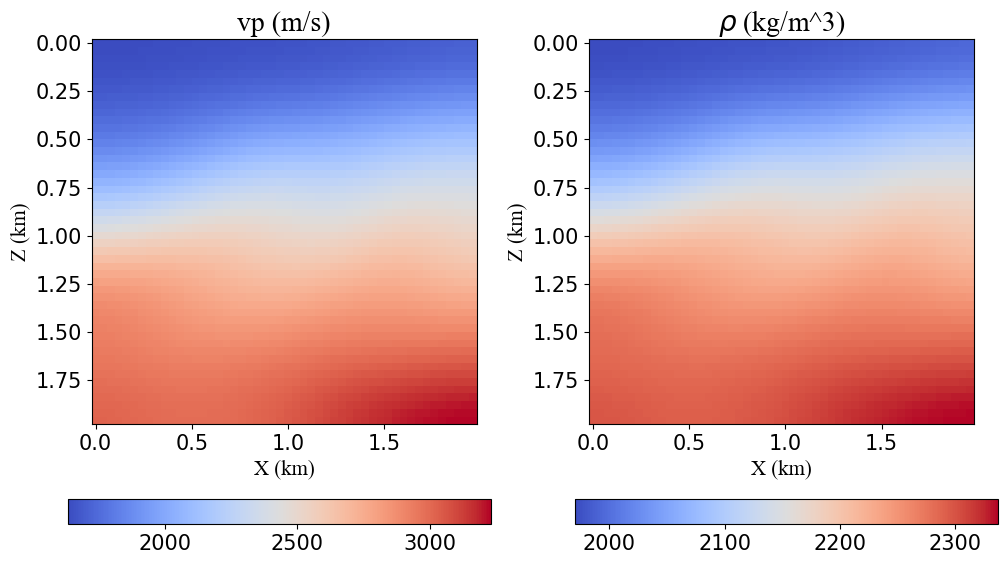

In [4]:
model._plot_vp_rho(figsize=(12,5),wspace=0.15,cbar_pad_fraction=0.2,cmap='coolwarm',save_path=os.path.join(project_path,"model/init_vp_rho.png"))

## Define the observed systems: Survey = Source + Receiver

In [5]:
# Define source positions in the model
src_z = np.array([45]) 
src_x = np.array([25])

# Generate wavelet for the source
src_t, src_v = wavelet(nt, dt, f0, amp0=1)  # Create time and wavelet amplitude
src_v = integrate.cumtrapz(src_v, axis=-1, initial=0)  # Integrate wavelet to get velocity

source = Source(nt=nt, dt=dt, f0=f0)  # Initialize source object

# Method 1: Add multiple sources at once (commented out)
# source.add_sources(src_x=src_x, src_z=src_z, src_wavelet=src_v, src_type='mt', src_mt=np.array([[1,0,0],[0,1,0],[0,0,1]]))

# Method 2: Loop through each source position to add them individually
for i in range(len(src_x)):
    source.add_source(src_x=src_x[i], src_z=src_z[i], src_wavelet=src_v, src_type="mt", src_mt=np.array([[1,0,0],[0,1,0],[0,0,1]]))


In [6]:
# Define receiver positions in the model
rcv_z = np.array([1  for i in range(0,nx,1)])
rcv_x = np.array([j  for j in range(0,nx,1)])

receiver = Receiver(nt=nt, dt=dt)  # Initialize receiver object

# Method 1: Add all receivers at once (commented out)
# receiver.add_receivers(rcv_x=rcv_x, rcv_z=rcv_z, rcv_type='pr')

# Method 2: Loop through each receiver position to add them individually
for i in range(len(rcv_x)):
    receiver.add_receiver(rcv_x=rcv_x[i], rcv_z=rcv_z[i], rcv_type="pr")

In [7]:
# Create a survey object using the defined source and receiver
survey = Survey(source=source, receiver=receiver)

# Print a representation of the survey object to check its configuration
print(survey.__repr__())

Survey Information:
Seismic Source:
  Source wavelet: 1600 samples at 3.00 ms
  Source number : 1
  Source types  : ['mt']
  Source x range: 25 - 25 (grids)
  Source z range: 45 - 45 (grids)

Seismic Receiver:
  Receiver data   : 1600 samples at 3.00 ms
  Receiver number : 50
  Receiver types  : ['pr']
  Receiver x range: 0 - 49 (grids)
  Receiver z range: 1 - 1 (grids)



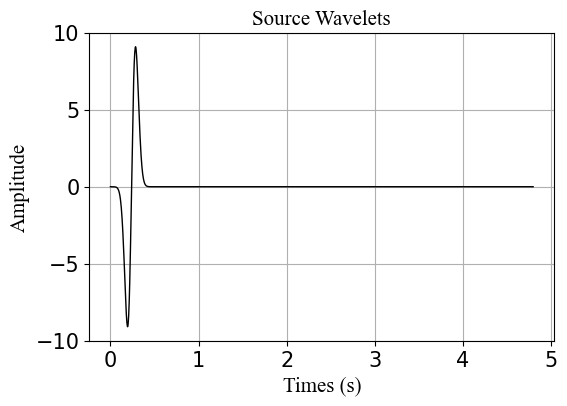

In [8]:
# Plot the wavelet used in the source
source.plot_wavelet(save_path=os.path.join(project_path, "survey/wavelets.png"))

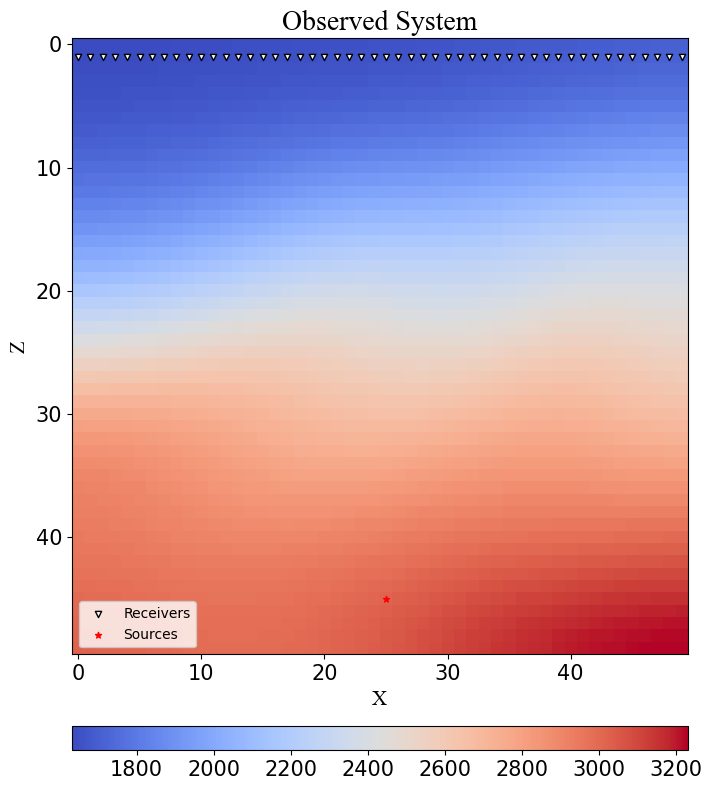

In [9]:
# Plot the survey configuration over the velocity model
survey.plot(model.vp,cmap='coolwarm',save_path=os.path.join(project_path,"survey/observed_system_init.png"))

## Define the propagator

In [10]:
# Initialize the wave propagator using the specified model and survey configuration
F = AcousticPropagator(model, survey, device=device)

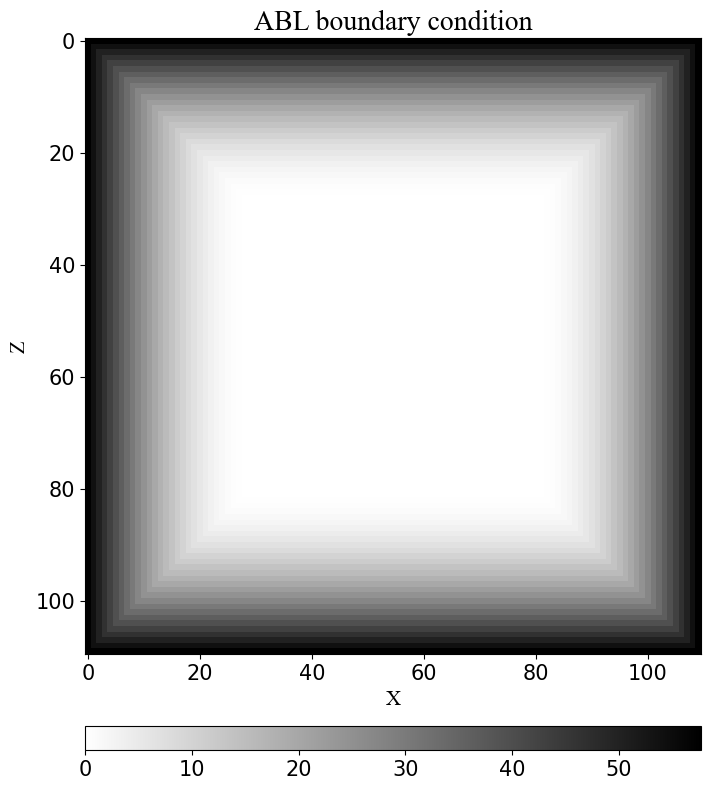

In [11]:
# Retrieve the damping array from the propagator and plot it to visualize boundary conditions
damp = F.damp
plot_damp(damp,save_path=os.path.join(project_path,"model/boundary_condition.png"))

## Load observed datasets

In [12]:
# Create an instance of SeismicData using the survey object.
d_obs = SeismicData(survey)

# Load observed waveform data from a specified file.
d_obs.load(os.path.join(project_path, "waveform/obs_data.npz"))

# Print a summary representation of the observed seismic data.
print(d_obs.__repr__())

Seismic Data:
  Source number : 1
  Receiver number : 50
  Time samples : 1600 samples at 3.00 ms



## Synthetic

In [13]:
# Perform the forward propagation to record waveforms
record_waveform = F.forward()

# Extract recorded pressure wavefield and particle velocities
rcv_p = record_waveform["p"]  # Recorded pressure wavefield
rcv_u = record_waveform["u"]  # Recorded particle velocity in x-direction
rcv_w = record_waveform["w"]  # Recorded particle velocity in z-direction

# Extract forward wavefields for analysis
forward_wavefield_p = record_waveform["forward_wavefield_p"]  # Forward pressure wavefield
forward_wavefield_u = record_waveform["forward_wavefield_u"]  # Forward particle velocity wavefield in x
forward_wavefield_w = record_waveform["forward_wavefield_w"]  # Forward particle velocity wavefield in z

In [14]:
d_syn = SeismicData(survey)
d_syn.record_data(record_waveform)
d_syn.save(os.path.join(project_path,"waveform/syn_data.npz"))

## Gradient Calculate

In [15]:
rcv_syn_p = rcv_p
rcv_obs_p = numpy2tensor(d_obs.data["p"]).to(device)

normalize = False
if normalize:
    rcv_obs_p = rcv_obs_p/(torch.max(torch.abs(rcv_obs_p),axis=1,keepdim=True).values)
    rcv_syn_p = rcv_syn_p/(torch.max(torch.abs(rcv_syn_p),axis=1,keepdim=True).values)

loss = torch.sum((rcv_obs_p - rcv_syn_p)**2)
loss.backward()

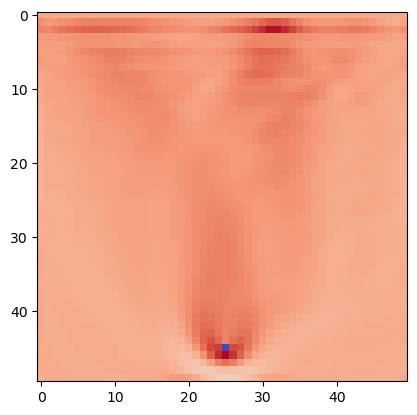

In [16]:
grad_vp = model.get_grad("vp")

plt.figure()
plt.imshow(grad_vp,cmap='coolwarm')
plt.show()

In [17]:
np.savez(os.path.join(project_path,"inversion-AD/grad_vp.npz"),data = grad_vp)